#### RFM Classs code but in JP nb

In [1]:


import matplotlib.pyplot as plt
import numpy
import pandas
import random
import sys

import seaborn
from datetime import datetime

# Set some options for printing all the columns
numpy.set_printoptions(precision = 10, threshold = sys.maxsize)
numpy.set_printoptions(linewidth = numpy.inf)

pandas.set_option('display.max_columns', None)
pandas.set_option('display.expand_frame_repr', False)
pandas.set_option('max_colwidth', None)

pandas.options.display.float_format = '{:,.10f}'.format


In [6]:

transaction = pandas.read_csv(r'G:\My Drive\PROFESSIONAL\MAS24\Courses\CSP571\data\\rfm_Transactions.csv')

transaction.sort_values(by=[ 'Date','CustomerID'], inplace=True)
transaction.head()

,CustomerID,ProductLine,ProductNumber,Date,Amount
0,300,B-200,228,1/1/2021,40
1,347,A-100,171,1/1/2021,36
2,373,E-500,571,1/1/2021,169
3,489,E-500,592,1/1/2021,182
4,507,D-400,438,1/1/2021,142


In [28]:
mm = transaction['Amount'] <0
transaction[mm]

,CustomerID,ProductLine,ProductNumber,Date,Amount


In [9]:
# Calculate Number of days since 12/31/2020

t_date = pandas.to_datetime(transaction['Date'], format='%m/%d/%Y')
reference_date = datetime.strptime('12/31/2020', "%m/%d/%Y")
n_days = pandas.Series((t_date - reference_date) / numpy.timedelta64(1, 'D'), name = 'N Days')

In [27]:


# Create the training data

train_data = transaction[['CustomerID', 'Date', 'Amount']].join(n_days)
train_data.tail()


,CustomerID,Date,Amount,N Days
3774,797,9/9/2021,158,252.0000000000
3775,805,9/9/2021,99,252.0000000000
3776,814,9/9/2021,213,252.0000000000
3777,834,9/9/2021,26,252.0000000000
3778,902,9/9/2021,61,252.0000000000


In [15]:

# Define the aggregation procedure outside of the groupby operation
aggregations = {
    'N Days':'max',
    'CustomerID': 'count',
    'Amount': 'sum'
}

column_map = {'N Days': 'Recency', 'CustomerID': 'Frequency', 'Amount': 'Monetary'}

customer_data = train_data.groupby('CustomerID').agg(aggregations).rename(columns = column_map)
rfm_names = customer_data.columns

In [31]:
customer_data.sort_values('Frequency', ascending=False)

,Recency,Frequency,Monetary,Recency Score,Frequency Score,Monetary Score,RFM Score
CustomerID,,,,,,,
465,336.0000000000,14,1074,4,5,5,455
225,359.0000000000,13,1104,5,5,5,555
386,361.0000000000,13,1488,5,5,5,555
448,238.0000000000,12,987,2,5,5,255
374,339.0000000000,12,768,5,5,5,555
...,...,...,...,...,...,...,...
396,34.0000000000,1,32,1,1,1,111
364,46.0000000000,1,81,1,1,1,111
964,206.0000000000,1,38,1,1,1,111


In [22]:

# Determine the quintiles
quintile = customer_data.describe(percentiles = [0.2, 0.4, 0.6, 0.8])


In [23]:
quintile

,Recency,Frequency,Monetary
count,995.0000000000,995.0000000000,995.0000000000
mean,277.6824120603,4.9306532663,466.4904522613
std,62.5627543479,2.2039417485,240.6347588824
min,30.0000000000,1.0000000000,12.0000000000
20%,228.0000000000,3.0000000000,254.8000000000
40%,269.0000000000,4.0000000000,381.0000000000
50%,285.0000000000,5.0000000000,436.0000000000
60%,302.0000000000,5.0000000000,505.4000000000
80%,336.0000000000,7.0000000000,665.0000000000
max,365.0000000000,14.0000000000,"1,488.0000000000"


In [24]:


# Assign customers to groups
customer_group = pandas.DataFrame(numpy.where(numpy.isnan(customer_data),0,1), index = customer_data.index)

for q in ['20%','40%','60%','80%']:
   customer_group = customer_group + numpy.where(customer_data[rfm_names] > quintile.loc[q][rfm_names], 1, 0)

customer_group = customer_group.rename(columns = {0: 'Recency Score', 1: 'Frequency Score', 2: 'Monetary Score'})

In [25]:
customer_group

,Recency Score,Frequency Score,Monetary Score
CustomerID,,,
1,3,3,3
2,5,2,2
3,1,1,1
4,3,4,5
5,1,1,2
...,...,...,...
996,1,1,1
997,1,1,1
998,3,1,1


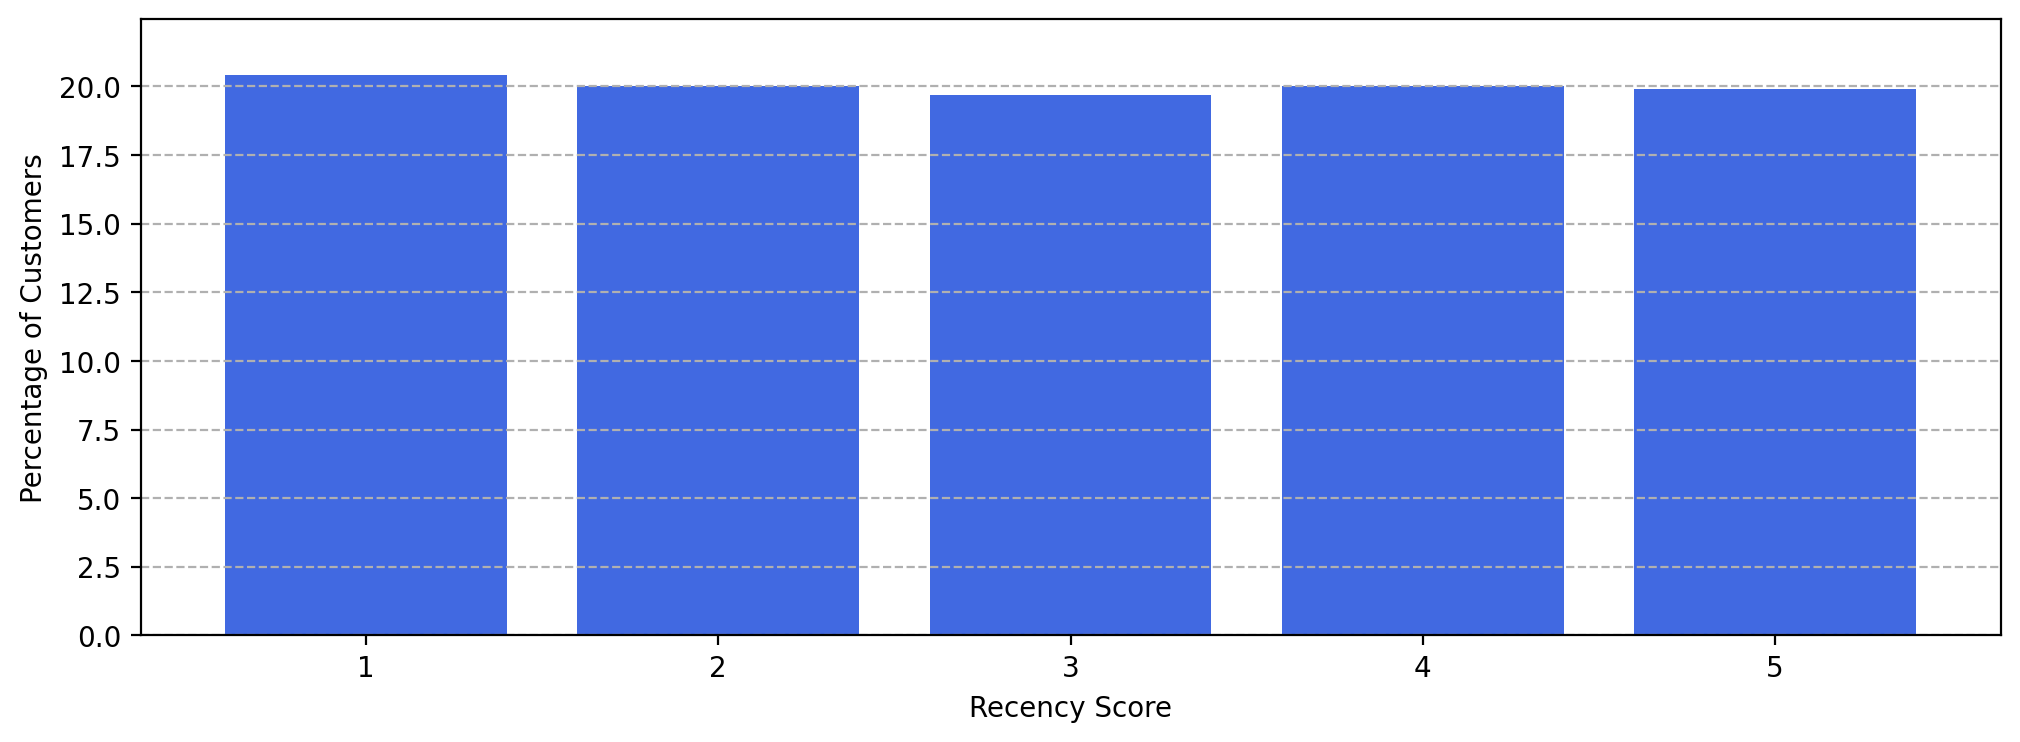

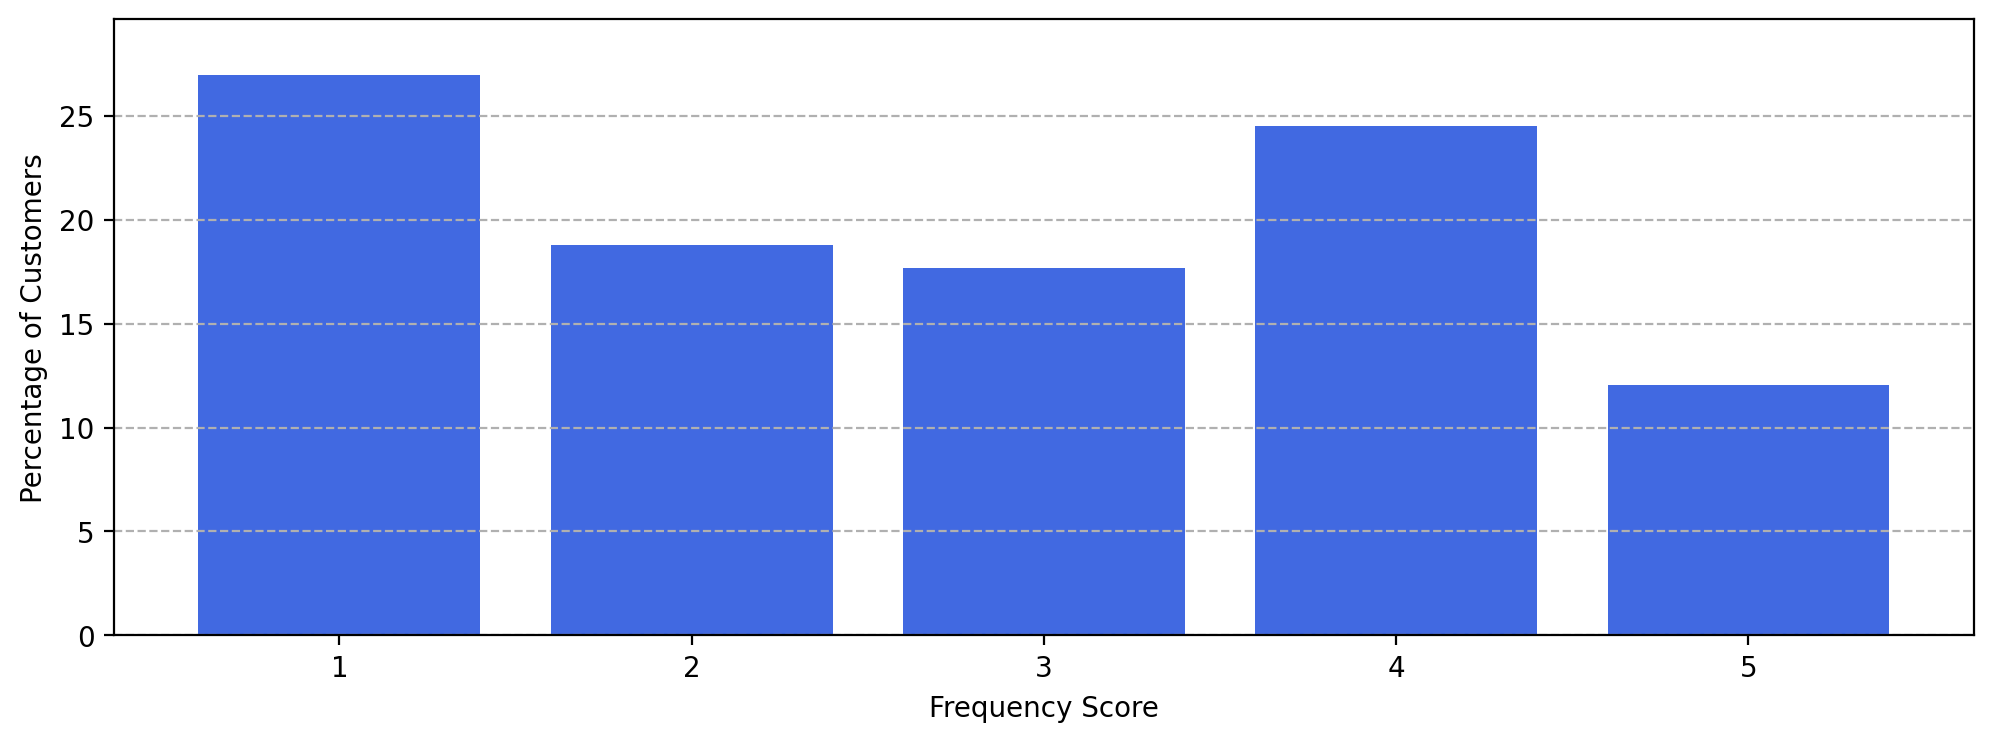

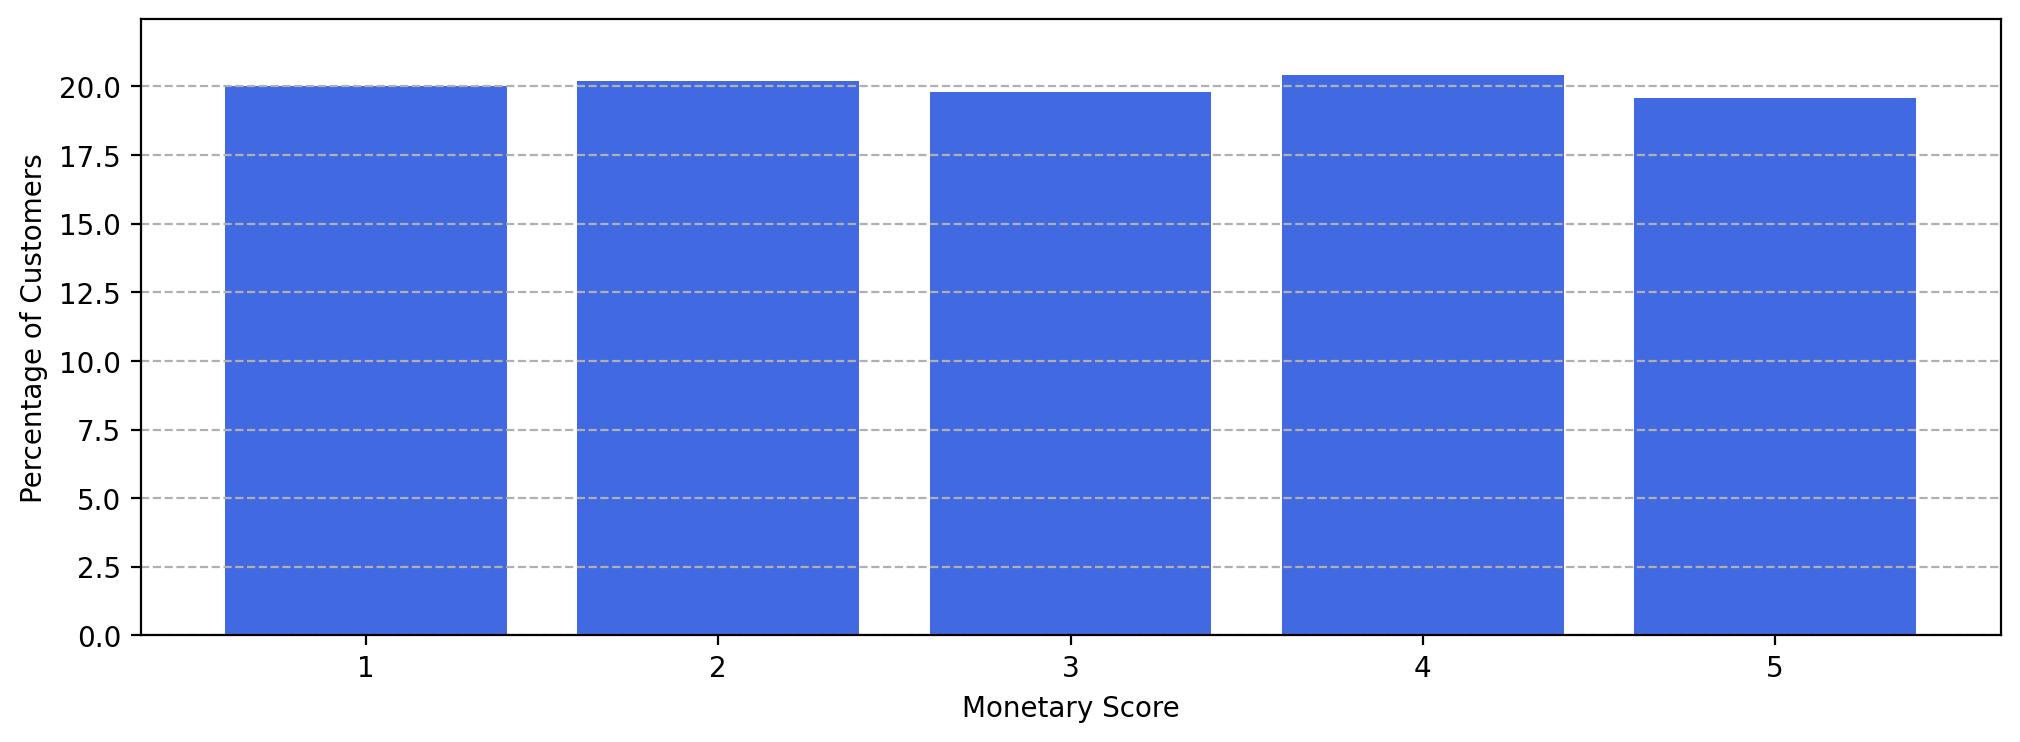

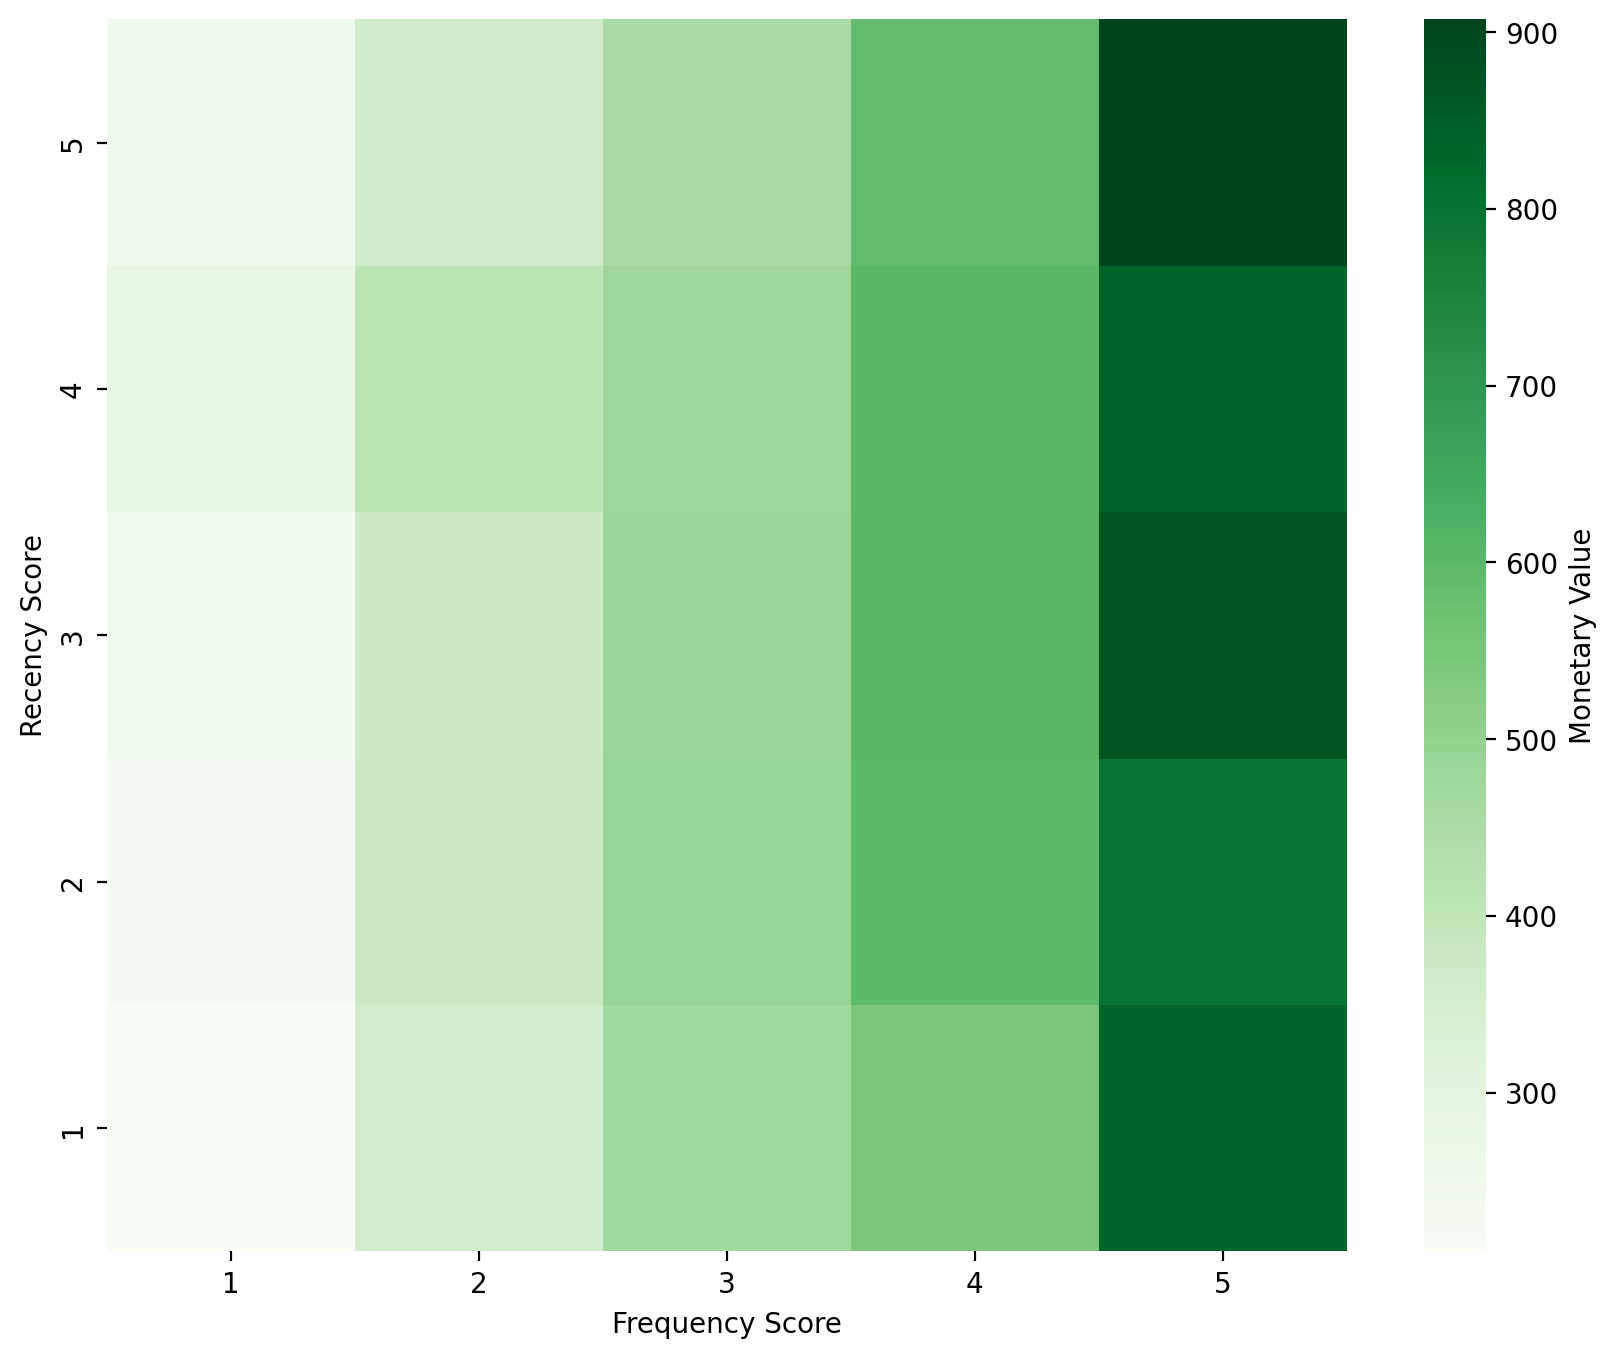

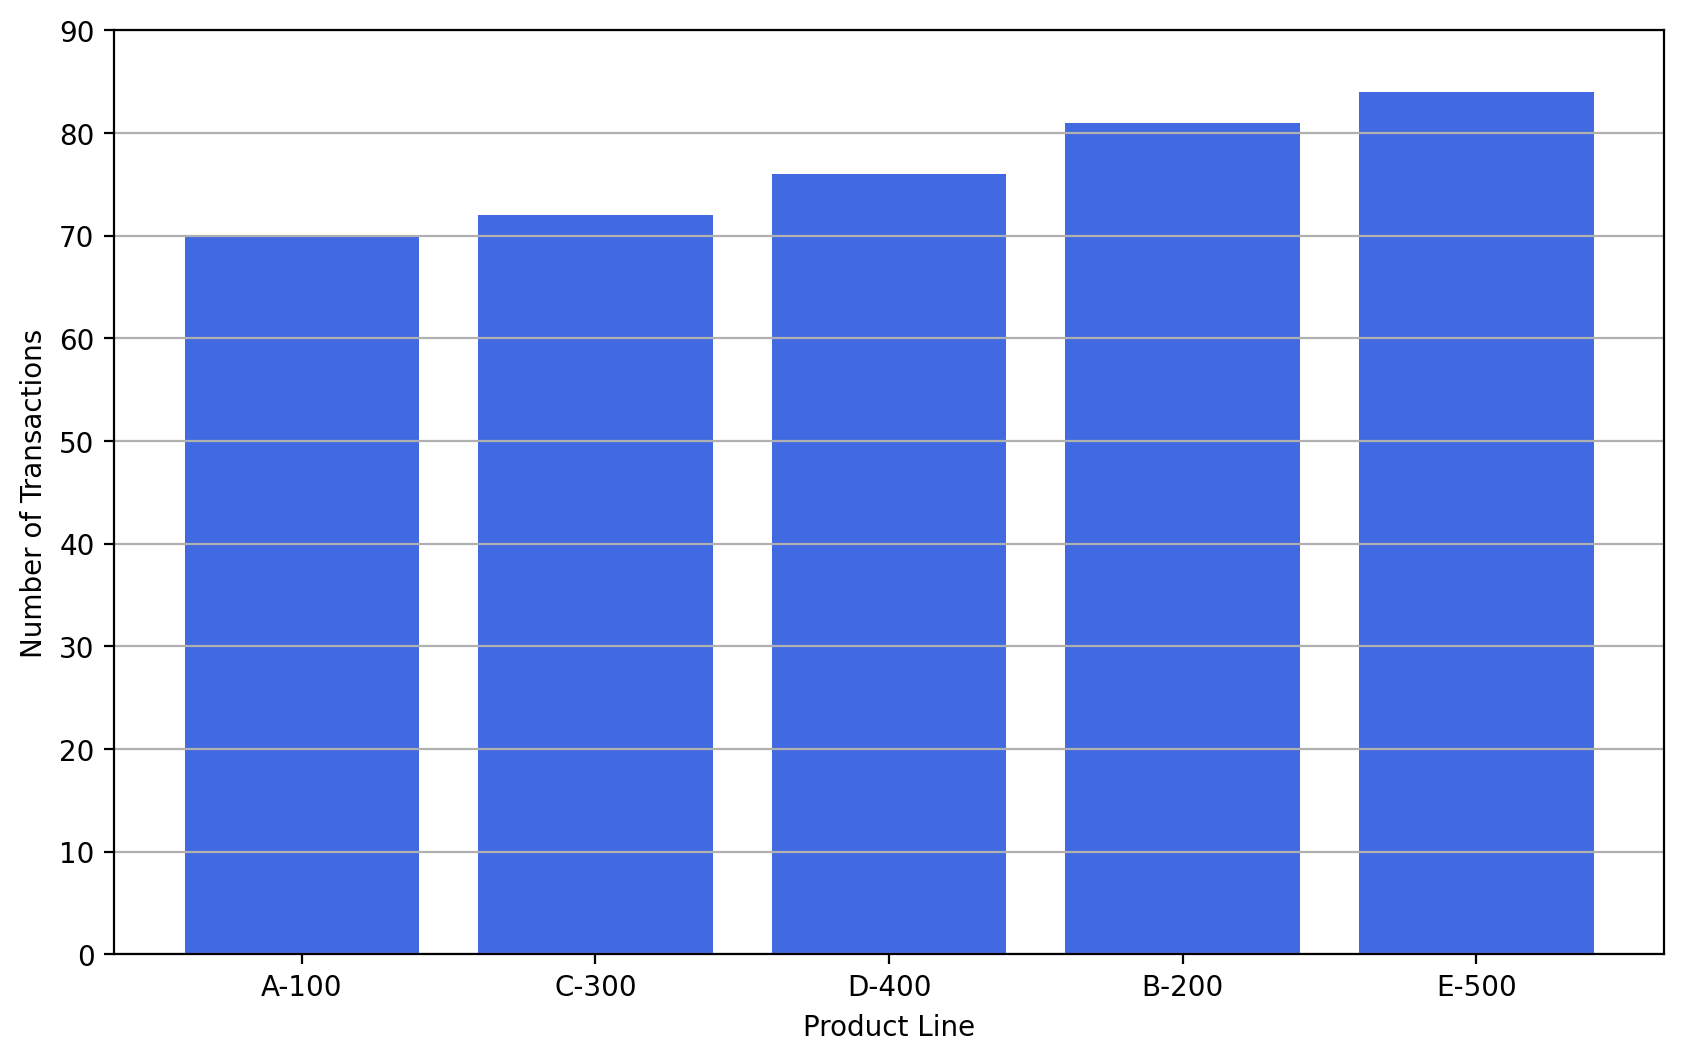

In [26]:



# Inspect bar charts of each group
for g in ['Recency Score', 'Frequency Score','Monetary Score']:
   group_prop = 100 * customer_group[g].value_counts(ascending = True, normalize = True)

   plt.figure(figsize = (12,4), dpi = 200)
   plt.bar(group_prop.index, group_prop, color = 'royalblue')
   plt.xlabel(g)
   plt.ylabel('Percentage of Customers')
   plt.xticks(range(1,6,1))
   plt.grid(axis = 'y', linestyle = '--')
   plt.margins(y = 0.1)
   plt.show()

# Merge the group assignments back to the customer data
customer_data = customer_data.join(customer_group)

customer_data['RFM Score'] = 100 * customer_data['Recency Score'] + 10 * customer_data['Frequency Score'] + customer_data['Monetary Score']

# Look at Monetary value by Recency and Frequency groups
xtab = pandas.crosstab(index = customer_data['Recency Score'], columns = customer_data['Frequency Score'],
                       values = customer_data['Monetary'], aggfunc = 'mean')
plt.figure(figsize = (10,8), dpi = 200)
seaborn.heatmap(xtab, cmap = 'Greens', cbar_kws={'label': 'Monetary Value'})
plt.gca().invert_yaxis()
plt.show()

# Copy the RFM Score back to the transaction data
transaction_rfm = transaction.merge(customer_data['RFM Score'], left_on = ['CustomerID'], right_on = customer_data.index)

# What kind of products do the customers with RFM score 555 buy?
focus_data = transaction_rfm[transaction_rfm['RFM Score'] == 555]

product_size = focus_data['ProductLine'].value_counts(ascending = True)

plt.figure(figsize = (10,6), dpi = 200)
plt.bar(product_size.index, product_size, color = 'royalblue')
plt.yticks(range(0,100,10))
plt.xlabel('Product Line')
plt.ylabel('Number of Transactions')
plt.grid(axis = 'y')
plt.show()
